In [19]:
import numpy as np
import random

import importlib
from pathlib import Path
import os

from backbone import sampler, draw, convolution

importlib.reload(sampler)
importlib.reload(draw)
importlib.reload(convolution)

from matplotlib import pyplot as plt

import torch
import torch.nn as nn

In [20]:
kernel_tensor_1, angles = convolution.make_gabor_kernels(ksize=7, sigma=2, lam=4)
kernel_tensor_2, _ = convolution.make_gabor_kernels(ksize=31, sigma=5, lam=15)

In [21]:
outdir = Path(os.getcwd()) / 'outputs'
os.makedirs(outdir, exist_ok=True)

Ps = np.random.uniform(size=(4,2))
#Ps = np.vstack([[0.2,0], Ps, [0.8,1]])
#Ps = np.array([[0.,0.], [0.1,0.9], [0.9,0.1], [1.,1.]])
#Ps = np.array([[0.,0.], [1.,1.]])

radius = 0.02
thresh = 1e-3

%time C, H = sampler.draw_positions(radius, sampler.bezier_curve(Ps), thresh=thresh)
%time D, _ = sampler.draw_positions(radius, sampler.box(), exclusions=C, thresh=thresh)

CPU times: user 479 ms, sys: 11.6 ms, total: 491 ms
Wall time: 490 ms
CPU times: user 18.1 s, sys: 63.4 ms, total: 18.2 s
Wall time: 18.3 s


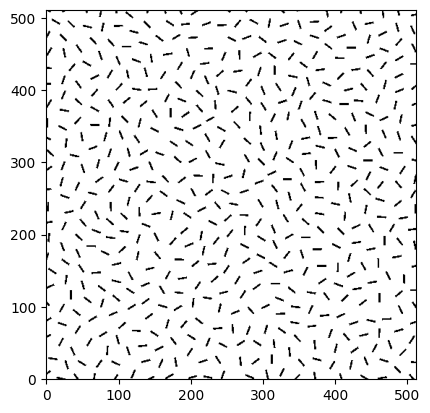

In [22]:
# Define the patch function

l=0.025
w=0.005
pfunc = lambda z,h: draw.segment(z, h, l, w)

N = 512
If, Tf = draw.generate_image(C, H, N=N, pfunc=pfunc)
Ig, Tg = draw.generate_image(D, N=N, pfunc=pfunc)

I = If + Ig

#image = torch.tensor(Ig)
#image_tensor = image.unsqueeze(0).unsqueeze(0)

#image_tensor = image_tensor.to(torch.float32)
kernel_tensor_1 = kernel_tensor_1.to(torch.float32)
kernel_tensor_2 = kernel_tensor_2.to(torch.float32)

plt.imshow(I, aspect='equal',origin= "lower", cmap='binary')

In [ ]:
for i in range(100 ):

    # --- Convert Ig to torch tensor ---
    img_np = Ig
    img_tensor = torch.tensor(img_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

    # --- First convolution ---
    conv1 = nn.functional.conv2d(
        img_tensor,
        kernel_tensor_1,
        stride=1,
        padding=3
    )

    # --- Second convolution ---
    conv2 = nn.functional.conv2d(
        conv1,
        kernel_tensor_2,
        stride=1,
        padding=15,
        groups=20
    )

    # --- Compute metrics of current Ig ---
    curr_mean = (conv2**2).mean(dim=[2, 3]).sum().item()
    curr_var = conv2.var(dim=[2, 3], unbiased=False).sum().item()

    # --- Build updated candidate image ---
    updated_img = img_np.copy()
    cluster_list = convolution.clusters(conv2)

    indices = random.sample(range(14), 7)
    
    for j in indices:
        val, ch_main, px, py = cluster_list[j]

        ch_weak, weak_val = convolution.weakest_channel(conv2, px, py)
        cx, cy = convolution.find_closest(img_np, px, py)
        connected = convolution.find_connected(img_np, cx, cy)
        outline = convolution.bounding_square(connected)
        x0, y0 = outline[0]
        x1, y1 = outline[1]
        side = outline[2]

        if x0 >= 0 and y0 >= 0 and x1 < 512 and y1 < 512:
            print((x0, x1, y0, y1))
            angle = angles[ch_weak] + random.uniform(-1, 1) * 0.1
            patch = convolution.draw_segment(angle, side)
            updated_img[y0:y1, x0:x1] = patch

    # --- Recompute conv2d on the candidate image (ALLOWED) ---
    cand_tensor = torch.tensor(updated_img, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    
    cand_conv1 = nn.functional.conv2d(
        cand_tensor, kernel_tensor_1,
        stride=1, padding=3
    )

    cand_conv2 = nn.functional.conv2d(
        cand_conv1, kernel_tensor_2,
        stride=1, padding=15,
        groups=20
    )

    # Metrics of candidate image
    cand_mean = (cand_conv2**2).mean(dim=[2, 3]).sum().item()
    cand_var = cand_conv2.var(dim=[2, 3], unbiased=False).sum().item()

    # --- UPDATE ONLY IF IMPROVED ---
    if cand_mean < curr_mean and cand_var < curr_var:
        Ig = updated_img
        print(f"Iter {i+1}: UPDATE | mean {curr_mean:.3f} → {cand_mean:.3f}, var {curr_var:.3f} → {cand_var:.3f}")
    else:
        # No update, but NO FREEZE — next iteration still proceeds
        print(f"Iter {i+1}: NO UPDATE | mean={curr_mean:.3f}, var={curr_var:.3f}")


(250, 266, 61, 77)
(226, 240, 130, 144)
(108, 122, 496, 510)
(201, 216, 341, 356)
(184, 198, 197, 211)
(311, 327, 233, 249)
(421, 436, 203, 218)
Iter 1: UPDATE | mean 5011.034 → 5008.014, var 5010.958 → 5007.938
(28, 42, 424, 438)
(262, 276, 42, 56)
(16, 30, 465, 479)
(400, 414, 197, 211)
(290, 304, 293, 307)
(475, 490, 371, 386)
(130, 146, 204, 220)
Iter 2: UPDATE | mean 5008.014 → 4996.902, var 5007.938 → 4996.826
(100, 116, 195, 211)
(306, 321, 150, 165)
(309, 323, 256, 270)
(132, 146, 483, 497)
(396, 412, 122, 138)
(132, 146, 483, 497)
(101, 115, 352, 366)
Iter 3: UPDATE | mean 4996.902 → 4994.492, var 4996.826 → 4994.416
(406, 420, 104, 118)
(38, 52, 188, 202)
(257, 273, 417, 433)
(437, 451, 251, 265)
(131, 144, 205, 218)
(351, 367, 187, 203)
(81, 97, 187, 203)
Iter 4: UPDATE | mean 4994.492 → 4989.633, var 4994.416 → 4989.557
(100, 115, 195, 210)
(401, 414, 412, 425)
(70, 84, 118, 132)
(119, 135, 185, 201)
(372, 386, 199, 213)
(42, 57, 14, 29)
(82, 96, 458, 472)
Iter 5: UPDATE | 

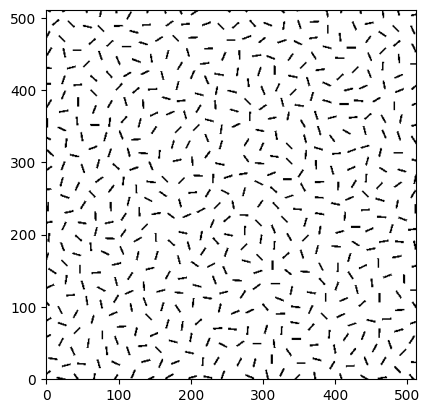

In [24]:
I = If + Ig

plt.imshow(I, aspect='equal',origin= "lower", cmap='binary')